# 07 -- GRU / LSTM + tabular MLP

Мы решаем регрессию `target_delay_s` с MAE и теперь отдельно моделируем саму последовательность телеметрии.

Я использую две ветки:

* recurrent encoder получает последние 30 минут телеметрии, собранные в минутные интервалы;
* MLP получает статические, расписательные и пространственные признаки из `02_feature_engineering.ipynb`.

После этого обе ветки объединяются и дают один прогноз задержки.

GRU и LSTM не фиксирую заранее -- тип recurrent блока выбирает Optuna. Для небольшого размеченного датасета это разумнее Transformer: параметров меньше, а временная структура GPS сохраняется напрямую.

Сравниваю две постановки:

* `direct` -- предсказываю `target_delay_s`;
* `residual` -- предсказываю изменение задержки `target_delay_s - cur_dev_s`, затем возвращаю `cur_dev_s`.

Основная оценка -- purged blocked CV по времени внутри реальных ТС. Validation содержит только реальные ТС, synthetic используется только в train с весом, который подбирает Optuna.

In [2]:
from pathlib import Path
import copy
import gc
import json
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

RNN_SEED = 143
RNN_SEQUENCE_STEPS = 30
RNN_STEP_SECONDS = 60
RNN_PURGE_MINUTES = 45
RNN_TUNE_FOLDS = 3
RNN_OOF_FOLDS = 5
RNN_STRESS_FOLDS = 3
RNN_TRIALS_PER_MODE = 30
RNN_FINAL_TRIALS = 15
RNN_MAX_EPOCHS = 160
RNN_EARLY_STOPPING = 18
RNN_LR_PATIENCE = 5
RNN_SPEED_CAP = 120.0
RNN_SYNTHETIC_WEIGHTS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
RNN_LEARNING_FRACTIONS = [0.25, 0.5, 0.75, 1.0]

RNN_DEVICE = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)

RNN_ARTIFACT_DIR = Path('../artifacts/models/sequence_rnn')
RNN_CHECKPOINT_DIR = RNN_ARTIFACT_DIR / 'checkpoints'
RNN_SUBMISSION_DIR = Path('../submissions/sequence_rnn')
RNN_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RNN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RNN_SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

RNN_DEVICE

device(type='mps')

## 1. Данные

`02_feature_engineering.ipynb` уже сохранил согласованные таблицы train / test / validate. Из них беру целевую остановку, `cur_dev_s` и статический контекст.

Сырую последовательность строю заново из `traffic.csv`. Для каждой прогнозной точки использую только пакеты с

`available_time = max(event_time, receive_time) <= T`.

Так поздно пришедшая телеметрия не появляется в прошлом задним числом.

In [3]:
rnn_features_dir = Path('../dataset/features')

rnn_train = pd.read_pickle(rnn_features_dir / 'train_features.pkl')
rnn_test = pd.read_pickle(rnn_features_dir / 'test_features.pkl')
rnn_validate = pd.read_pickle(rnn_features_dir / 'validate_features.pkl')

rnn_feature_cols = pd.read_csv(
    rnn_features_dir / 'feature_columns.csv'
).feature.tolist()

rnn_train_traffic = pd.read_csv('../dataset/train/traffic.csv', low_memory=False)
rnn_test_traffic = pd.read_csv('../dataset/test/traffic.csv', low_memory=False)
rnn_validate_traffic = pd.read_csv('../dataset/validate/traffic.csv', low_memory=False)

pd.Series({
    'device': str(RNN_DEVICE),
    'train_rows': len(rnn_train),
    'test_rows': len(rnn_test),
    'validate_rows': len(rnn_validate),
    'train_real_rows': (rnn_train.tr_id < 9_000_000).sum(),
    'train_synthetic_rows': (rnn_train.tr_id >= 9_000_000).sum(),
})

device                   mps
train_rows              4434
test_rows                353
validate_rows            151
train_real_rows         1141
train_synthetic_rows    3293
dtype: object

In [4]:
assert rnn_train[['stop_lon', 'stop_lat']].notna().all().all()
assert rnn_test[['stop_lon', 'stop_lat']].notna().all().all()
assert rnn_validate[['stop_lon', 'stop_lat']].notna().all().all()
assert 'target_delay_s' not in rnn_feature_cols
assert len(set(rnn_train.sample_id) & set(rnn_test.sample_id)) == 0

## 2. Последовательность телеметрии

30 минут делю на 30 минутных интервалов. Такой формат устойчивее исходной нерегулярной частоты пакетов и дает одинаковую длину входа для каждого прогноза.

В каждом интервале оставляю физически понятные величины: число пакетов, качество GPS, скорость, долю стоянки, направление, задержку доставки пакета и положение относительно целевой остановки.

In [5]:
def rnn_prepare_traffic(data):
    rnn_data = data.copy()

    for rnn_col in ['event_time', 'receive_time', 'gps_time']:
        rnn_data[rnn_col] = pd.to_datetime(rnn_data[rnn_col], errors='coerce')

    rnn_data['available_time'] = rnn_data[['event_time', 'receive_time']].max(axis=1)
    rnn_data['speed_clean'] = rnn_data.speed.clip(0, RNN_SPEED_CAP)
    rnn_data['speed_outlier'] = rnn_data.speed.gt(RNN_SPEED_CAP).fillna(False)
    rnn_data['receive_lag_s'] = (
        rnn_data.receive_time - rnn_data.event_time
    ).dt.total_seconds()
    rnn_data['gps_event_lag_s'] = (
        rnn_data.event_time - rnn_data.gps_time
    ).dt.total_seconds()
    rnn_data['valid_coords'] = (
        rnn_data.location_valid
        & rnn_data.lon.notna()
        & rnn_data.lat.notna()
    )

    return rnn_data.sort_values(
        ['tr_id', 'available_time']
    ).reset_index(drop=True)

In [6]:
rnn_train_traffic = rnn_prepare_traffic(rnn_train_traffic)
rnn_test_traffic = rnn_prepare_traffic(rnn_test_traffic)
rnn_validate_traffic = rnn_prepare_traffic(rnn_validate_traffic)

In [7]:
def rnn_make_traffic_groups(traffic):
    rnn_groups = {}

    for rnn_tr_id, rnn_group in traffic.groupby('tr_id', sort=False):
        rnn_groups[int(rnn_tr_id)] = {
            'available': rnn_group.available_time.to_numpy(
                dtype='datetime64[ns]'
            ).astype('int64'),
            'speed': rnn_group.speed_clean.to_numpy(float),
            'heading': rnn_group.heading.to_numpy(float),
            'lon': rnn_group.lon.to_numpy(float),
            'lat': rnn_group.lat.to_numpy(float),
            'valid': rnn_group.valid_coords.to_numpy(bool),
            'hist': rnn_group.is_hist_data.to_numpy(bool),
            'receive_lag': rnn_group.receive_lag_s.to_numpy(float),
            'gps_lag': rnn_group.gps_event_lag_s.to_numpy(float),
            'speed_outlier': rnn_group.speed_outlier.to_numpy(bool),
        }

    return rnn_groups

In [8]:
rnn_train_groups = rnn_make_traffic_groups(rnn_train_traffic)
rnn_test_groups = rnn_make_traffic_groups(rnn_test_traffic)
rnn_validate_groups = rnn_make_traffic_groups(rnn_validate_traffic)

In [9]:
def rnn_signed_log1p(values):
    return np.sign(values) * np.log1p(np.abs(values))

In [10]:
RNN_SEQUENCE_FEATURES = [
    'packet_log1p',
    'valid_share',
    'hist_share',
    'speed_mean_kmh',
    'speed_std_kmh',
    'speed_last_kmh',
    'stopped_share',
    'heading_sin',
    'heading_cos',
    'receive_lag_signed_log1p',
    'gps_lag_signed_log1p',
    'target_dx_km',
    'target_dy_km',
    'target_distance_km',
    'has_valid_location',
    'speed_outlier_share',
]

In [11]:
def rnn_build_sequences(points, traffic_groups):
    rnn_sequences = np.full(
        (
            len(points),
            RNN_SEQUENCE_STEPS,
            len(RNN_SEQUENCE_FEATURES)
        ),
        np.nan,
        dtype=np.float32
    )

    rnn_cols = ['tr_id', 'T', 'stop_lon', 'stop_lat']

    for rnn_row, rnn_values in enumerate(
        points[rnn_cols].itertuples(index=False, name=None)
    ):
        rnn_tr_id, rnn_T, rnn_target_lon, rnn_target_lat = rnn_values
        rnn_group = traffic_groups[int(rnn_tr_id)]

        rnn_end = pd.Timestamp(rnn_T).value
        rnn_start = (
            rnn_end
            - RNN_SEQUENCE_STEPS
            * RNN_STEP_SECONDS
            * 1_000_000_000
        )

        rnn_left = np.searchsorted(
            rnn_group['available'], rnn_start, side='left'
        )
        rnn_right = np.searchsorted(
            rnn_group['available'], rnn_end, side='right'
        )

        if rnn_right <= rnn_left:
            continue

        rnn_available = rnn_group['available'][rnn_left:rnn_right]
        rnn_age_s = (rnn_end - rnn_available) / 1e9
        rnn_bins = (
            RNN_SEQUENCE_STEPS
            - 1
            - np.floor(rnn_age_s / RNN_STEP_SECONDS).astype(int)
        )

        rnn_in_window = (
            (rnn_bins >= 0)
            & (rnn_bins < RNN_SEQUENCE_STEPS)
        )
        rnn_bins = rnn_bins[rnn_in_window]
        rnn_indices = np.arange(rnn_left, rnn_right)[rnn_in_window]

        for rnn_bin in np.unique(rnn_bins):
            rnn_idx = rnn_indices[rnn_bins == rnn_bin]
            rnn_speed = rnn_group['speed'][rnn_idx]
            rnn_speed = rnn_speed[np.isfinite(rnn_speed)]
            rnn_valid = rnn_group['valid'][rnn_idx]

            rnn_sequences[rnn_row, rnn_bin, 0] = np.log1p(len(rnn_idx))
            rnn_sequences[rnn_row, rnn_bin, 1] = rnn_valid.mean()
            rnn_sequences[rnn_row, rnn_bin, 2] = rnn_group['hist'][rnn_idx].mean()
            rnn_sequences[rnn_row, rnn_bin, 15] = (
                rnn_group['speed_outlier'][rnn_idx].mean()
            )

            if len(rnn_speed):
                rnn_sequences[rnn_row, rnn_bin, 3] = rnn_speed.mean()
                rnn_sequences[rnn_row, rnn_bin, 4] = rnn_speed.std()
                rnn_sequences[rnn_row, rnn_bin, 5] = rnn_speed[-1]
                rnn_sequences[rnn_row, rnn_bin, 6] = (
                    rnn_speed <= 1
                ).mean()

            rnn_heading = rnn_group['heading'][rnn_idx]
            rnn_heading = rnn_heading[np.isfinite(rnn_heading)]

            if len(rnn_heading):
                rnn_heading_rad = np.radians(rnn_heading)
                rnn_sequences[rnn_row, rnn_bin, 7] = np.sin(
                    rnn_heading_rad
                ).mean()
                rnn_sequences[rnn_row, rnn_bin, 8] = np.cos(
                    rnn_heading_rad
                ).mean()

            rnn_receive_lag = rnn_group['receive_lag'][rnn_idx]
            rnn_receive_lag = rnn_receive_lag[np.isfinite(rnn_receive_lag)]

            if len(rnn_receive_lag):
                rnn_sequences[rnn_row, rnn_bin, 9] = rnn_signed_log1p(
                    np.median(rnn_receive_lag)
                )

            rnn_gps_lag = rnn_group['gps_lag'][rnn_idx]
            rnn_gps_lag = rnn_gps_lag[np.isfinite(rnn_gps_lag)]

            if len(rnn_gps_lag):
                rnn_sequences[rnn_row, rnn_bin, 10] = rnn_signed_log1p(
                    np.median(rnn_gps_lag)
                )

            rnn_valid_idx = rnn_idx[
                rnn_valid
                & np.isfinite(rnn_group['lon'][rnn_idx])
                & np.isfinite(rnn_group['lat'][rnn_idx])
            ]

            if len(rnn_valid_idx):
                rnn_last = rnn_valid_idx[-1]
                rnn_lon = rnn_group['lon'][rnn_last]
                rnn_lat = rnn_group['lat'][rnn_last]
                rnn_lon_scale = (
                    111.32 * np.cos(np.radians(rnn_target_lat))
                )

                rnn_dx = (rnn_lon - rnn_target_lon) * rnn_lon_scale
                rnn_dy = (rnn_lat - rnn_target_lat) * 111.32

                rnn_sequences[rnn_row, rnn_bin, 11] = rnn_dx
                rnn_sequences[rnn_row, rnn_bin, 12] = rnn_dy
                rnn_sequences[rnn_row, rnn_bin, 13] = np.hypot(
                    rnn_dx, rnn_dy
                )
                rnn_sequences[rnn_row, rnn_bin, 14] = 1.0
            else:
                rnn_sequences[rnn_row, rnn_bin, 14] = 0.0

    return rnn_sequences

In [12]:
rnn_train_sequences = rnn_build_sequences(
    rnn_train,
    rnn_train_groups
)
rnn_test_sequences = rnn_build_sequences(
    rnn_test,
    rnn_test_groups
)
rnn_validate_sequences = rnn_build_sequences(
    rnn_validate,
    rnn_validate_groups
)

pd.DataFrame({
    'split': ['train', 'test', 'validate'],
    'rows': [
        len(rnn_train_sequences),
        len(rnn_test_sequences),
        len(rnn_validate_sequences)
    ],
    'finite_share': [
        np.isfinite(rnn_train_sequences).mean(),
        np.isfinite(rnn_test_sequences).mean(),
        np.isfinite(rnn_validate_sequences).mean()
    ]
})

,split,rows,finite_share
0,train,4434,0.965493
1,test,353,0.978199
2,validate,151,0.972185


In [13]:
rnn_sequence_presence = pd.DataFrame({
    'feature': RNN_SEQUENCE_FEATURES,
    'missing_share': np.isnan(rnn_train_sequences).mean(axis=(0, 1))
}).sort_values('missing_share', ascending=False)

rnn_sequence_presence

,feature,missing_share
11,target_dx_km,0.105473
12,target_dy_km,0.105473
13,target_distance_km,0.105473
3,speed_mean_kmh,0.018321
4,speed_std_kmh,0.018321
5,speed_last_kmh,0.018321
6,stopped_share,0.018321
7,heading_sin,0.018321
8,heading_cos,0.018321
10,gps_lag_signed_log1p,0.018321


## 3. Tabular branch

Оконные `w1m_...w30m_` признаки здесь намеренно не подаю в MLP -- их роль выполняет recurrent ветка.

Также исключаю `pca_core_*` и автоматически выбранные log-преобразования из `02_`: их состав определялся на всем train. Для строгого CV оставляю только исходные детерминированные numeric features, а imputer и scaler fit'ю заново внутри каждого fold.

In [14]:
def rnn_select_tabular_features(data, feature_cols):
    rnn_window_prefixes = (
        'w1m_', 'w3m_', 'w5m_',
        'w10m_', 'w15m_', 'w30m_'
    )

    return [
        rnn_col
        for rnn_col in feature_cols
        if pd.api.types.is_numeric_dtype(data[rnn_col].dtype)
        and not rnn_col.startswith(rnn_window_prefixes)
        and not rnn_col.startswith('pca_core_')
        and not rnn_col.endswith(('_log1p', '_signed_log1p'))
    ]

In [15]:
rnn_tabular_features = rnn_select_tabular_features(
    rnn_train,
    rnn_feature_cols
)

rnn_train_tabular = rnn_train[rnn_tabular_features].to_numpy(float)
rnn_test_tabular = rnn_test[rnn_tabular_features].to_numpy(float)
rnn_validate_tabular = rnn_validate[rnn_tabular_features].to_numpy(float)

pd.Series({
    'sequence_features_per_step': len(RNN_SEQUENCE_FEATURES),
    'sequence_steps': RNN_SEQUENCE_STEPS,
    'tabular_features': len(rnn_tabular_features),
})

sequence_features_per_step     16
sequence_steps                 30
tabular_features              177
dtype: int64

In [16]:
assert not any(
    rnn_col.startswith('pca_core_')
    for rnn_col in rnn_tabular_features
)
assert not any(
    rnn_col.startswith(('w1m_', 'w3m_', 'w5m_', 'w10m_', 'w15m_', 'w30m_'))
    for rnn_col in rnn_tabular_features
)
assert np.isfinite(rnn_train_tabular[~np.isnan(rnn_train_tabular)]).all()
assert np.isfinite(rnn_train_sequences[~np.isnan(rnn_train_sequences)]).all()

## 4. CV без временной утечки

Внутри каждого реального `tr_id` точки упорядочиваю по `T` и разбиваю на последовательные блоки.

Для validation-блока удаляю из train точки того же ТС в радиусе 45 минут. Это покрывает максимальные 30 минут истории + 15 минут до целевого прибытия.

Synthetic никогда не попадает в validation.

In [17]:
def rnn_build_purged_folds(data, n_splits):
    rnn_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    rnn_frame['T'] = pd.to_datetime(rnn_frame['T'])
    rnn_frame['is_synthetic'] = rnn_frame.tr_id >= 9_000_000
    rnn_frame['cv_fold'] = -1

    rnn_real = rnn_frame.loc[~rnn_frame.is_synthetic]

    for rnn_tr_id, rnn_idx in rnn_real.groupby('tr_id').groups.items():
        rnn_ordered = rnn_frame.loc[rnn_idx].sort_values('T').index.to_numpy()

        for rnn_fold, rnn_chunk in enumerate(
            np.array_split(rnn_ordered, n_splits)
        ):
            rnn_frame.loc[rnn_chunk, 'cv_fold'] = rnn_fold

    rnn_folds = []
    rnn_purge = pd.Timedelta(minutes=RNN_PURGE_MINUTES)

    for rnn_fold in range(n_splits):
        rnn_valid_mask = (
            (~rnn_frame.is_synthetic)
            & (rnn_frame.cv_fold == rnn_fold)
        )
        rnn_train_mask = ~rnn_valid_mask

        for rnn_tr_id, rnn_valid_part in rnn_frame.loc[
            rnn_valid_mask
        ].groupby('tr_id'):
            rnn_left = rnn_valid_part['T'].min() - rnn_purge
            rnn_right = rnn_valid_part['T'].max() + rnn_purge
            rnn_near_valid = (
                (~rnn_frame.is_synthetic)
                & (rnn_frame.tr_id == rnn_tr_id)
                & rnn_frame['T'].between(rnn_left, rnn_right)
            )
            rnn_train_mask &= ~rnn_near_valid

        rnn_folds.append((
            np.flatnonzero(rnn_train_mask.to_numpy()),
            np.flatnonzero(rnn_valid_mask.to_numpy())
        ))

    return rnn_folds

In [18]:
def rnn_check_folds(data, folds):
    rnn_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    rnn_frame['T'] = pd.to_datetime(rnn_frame['T'])
    rnn_rows = []

    for rnn_fold, (rnn_train_idx, rnn_valid_idx) in enumerate(folds):
        rnn_train_part = rnn_frame.iloc[rnn_train_idx]
        rnn_valid_part = rnn_frame.iloc[rnn_valid_idx]
        rnn_min_gap = np.inf

        for rnn_tr_id, rnn_valid_tr in rnn_valid_part.groupby('tr_id'):
            rnn_train_times = rnn_train_part.loc[
                rnn_train_part.tr_id == rnn_tr_id,
                'T'
            ]

            if len(rnn_train_times) == 0:
                continue

            rnn_gap = np.abs(
                rnn_train_times.to_numpy()[:, None]
                - rnn_valid_tr['T'].to_numpy()[None, :]
            ).min()
            rnn_min_gap = min(
                rnn_min_gap,
                rnn_gap / np.timedelta64(1, 'm')
            )

        rnn_rows.append({
            'fold': rnn_fold,
            'train_rows': len(rnn_train_idx),
            'valid_rows': len(rnn_valid_idx),
            'valid_tr_ids': rnn_valid_part.tr_id.nunique(),
            'min_same_tr_gap_min': rnn_min_gap,
            'synthetic_valid_rows': (
                rnn_valid_part.tr_id >= 9_000_000
            ).sum(),
        })

    rnn_result = pd.DataFrame(rnn_rows)
    assert (rnn_result.min_same_tr_gap_min >= RNN_PURGE_MINUTES).all()
    assert (rnn_result.synthetic_valid_rows == 0).all()

    return rnn_result

In [19]:
def rnn_build_group_stress_folds(data, n_splits):
    rnn_real_idx = np.flatnonzero(
        (data.tr_id < 9_000_000).to_numpy()
    )
    rnn_synthetic_idx = np.flatnonzero(
        (data.tr_id >= 9_000_000).to_numpy()
    )

    rnn_splitter = GroupKFold(n_splits=n_splits)
    rnn_folds = []

    for rnn_real_train_local, rnn_real_valid_local in rnn_splitter.split(
        rnn_real_idx,
        groups=data.iloc[rnn_real_idx].tr_id
    ):
        rnn_train_idx = np.concatenate([
            rnn_real_idx[rnn_real_train_local],
            rnn_synthetic_idx
        ])
        rnn_valid_idx = rnn_real_idx[rnn_real_valid_local]
        rnn_folds.append((rnn_train_idx, rnn_valid_idx))

    return rnn_folds

In [20]:
rnn_tune_folds = rnn_build_purged_folds(
    rnn_train,
    RNN_TUNE_FOLDS
)
rnn_oof_folds = rnn_build_purged_folds(
    rnn_train,
    RNN_OOF_FOLDS
)
rnn_stress_folds = rnn_build_group_stress_folds(
    rnn_train,
    RNN_STRESS_FOLDS
)

rnn_fold_audit = rnn_check_folds(
    rnn_train,
    rnn_oof_folds
)
rnn_fold_audit

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min,synthetic_valid_rows
0,0,4130,233,13,50.0,0
1,1,4042,231,13,50.0,0
2,2,4082,228,13,50.0,0
3,3,4060,226,13,50.0,0
4,4,4149,223,13,50.0,0


## 5. Fold-wise preprocessing

Все параметры масштаба считаю только по train части конкретного fold.

Для sequence branch отдельно считаю mean/std каждого канала по всем train-интервалам. Пропуски после нормализации становятся нулем, то есть средним train, а наличие данных явно отражают `packet_log1p`, `valid_share` и `has_valid_location`.

Tabular branch получает median imputation + StandardScaler только по fold-train.

In [21]:
def rnn_fit_sequence_scaler(sequence):
    rnn_flat = sequence.reshape(-1, sequence.shape[-1]).astype(float)
    rnn_finite = np.isfinite(rnn_flat)
    rnn_count = rnn_finite.sum(axis=0)

    rnn_sum = np.where(rnn_finite, rnn_flat, 0).sum(axis=0)
    rnn_mean = np.divide(
        rnn_sum,
        rnn_count,
        out=np.zeros(rnn_flat.shape[1], dtype=float),
        where=rnn_count > 0
    )

    rnn_sq = np.where(
        rnn_finite,
        (rnn_flat - rnn_mean) ** 2,
        0
    ).sum(axis=0)
    rnn_var = np.divide(
        rnn_sq,
        rnn_count,
        out=np.ones(rnn_flat.shape[1], dtype=float),
        where=rnn_count > 0
    )
    rnn_std = np.sqrt(rnn_var)
    rnn_std[rnn_std < 1e-6] = 1.0

    return rnn_mean.astype(np.float32), rnn_std.astype(np.float32)

In [22]:
def rnn_transform_sequence(sequence, mean, std):
    rnn_scaled = (sequence - mean[None, None, :]) / std[None, None, :]
    return np.nan_to_num(
        rnn_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    ).astype(np.float32)

In [23]:
def rnn_set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

In [24]:
def rnn_sample_weight(data, synthetic_weight):
    return np.where(
        data.tr_id.to_numpy() >= 9_000_000,
        synthetic_weight,
        1.0
    ).astype(np.float32)

In [25]:
def rnn_clip_bounds(target, clip_name):
    if clip_name == 'none':
        return None

    rnn_q = {
        'q995': 0.995,
        'q999': 0.999,
    }[clip_name]

    rnn_lower = np.quantile(target, 1 - rnn_q)
    rnn_upper = np.quantile(target, rnn_q)
    return float(rnn_lower), float(rnn_upper)

In [26]:
def rnn_apply_clip(prediction, bounds):
    if bounds is None:
        return prediction

    return np.clip(prediction, bounds[0], bounds[1])

## 6. Dataset и модель

Recurrent hidden state кодирует динамику последних минут. MLP кодирует статический контекст. В fusion head использую LayerNorm, SiLU и dropout.

`bidirectional=True` здесь не является утечкой: обе стороны видят только уже известное окно до `T`, а не будущую телеметрию.

In [27]:
class RNNRegressionDataset(Dataset):
    def __init__(
        self,
        sequence,
        tabular,
        target_scaled,
        sample_weight,
        cur_dev,
        target_raw
    ):
        self.sequence = torch.as_tensor(sequence, dtype=torch.float32)
        self.tabular = torch.as_tensor(tabular, dtype=torch.float32)
        self.target_scaled = torch.as_tensor(
            target_scaled,
            dtype=torch.float32
        )
        self.sample_weight = torch.as_tensor(
            sample_weight,
            dtype=torch.float32
        )
        self.cur_dev = torch.as_tensor(cur_dev, dtype=torch.float32)
        self.target_raw = torch.as_tensor(target_raw, dtype=torch.float32)

    def __len__(self):
        return len(self.target_raw)

    def __getitem__(self, index):
        return (
            self.sequence[index],
            self.tabular[index],
            self.target_scaled[index],
            self.sample_weight[index],
            self.cur_dev[index],
            self.target_raw[index]
        )

In [28]:
class SequenceTabularRegressor(nn.Module):
    def __init__(
        self,
        sequence_dim,
        tabular_dim,
        rnn_type,
        hidden_size,
        num_layers,
        bidirectional,
        rnn_dropout,
        tabular_hidden,
        fusion_hidden,
        mlp_dropout
    ):
        super().__init__()

        rnn_class = nn.GRU if rnn_type == 'GRU' else nn.LSTM
        recurrent_dropout = rnn_dropout if num_layers > 1 else 0.0

        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        self.recurrent = rnn_class(
            input_size=sequence_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=recurrent_dropout,
            bidirectional=bidirectional
        )

        recurrent_dim = hidden_size * (2 if bidirectional else 1)
        tabular_out = max(32, tabular_hidden // 2)

        self.tabular = nn.Sequential(
            nn.Linear(tabular_dim, tabular_hidden),
            nn.LayerNorm(tabular_hidden),
            nn.SiLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(tabular_hidden, tabular_out),
            nn.SiLU(),
            nn.Dropout(mlp_dropout / 2)
        )

        self.head = nn.Sequential(
            nn.Linear(recurrent_dim + tabular_out, fusion_hidden),
            nn.LayerNorm(fusion_hidden),
            nn.SiLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(fusion_hidden, 1)
        )

    def forward(self, sequence, tabular):
        recurrent_output = self.recurrent(sequence)
        hidden = recurrent_output[1]

        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            sequence_embedding = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )
        else:
            sequence_embedding = hidden[-1]

        tabular_embedding = self.tabular(tabular)
        fused = torch.cat(
            [sequence_embedding, tabular_embedding],
            dim=1
        )

        return self.head(fused).squeeze(1)

In [29]:
def rnn_make_model(params, sequence_dim, tabular_dim):
    return SequenceTabularRegressor(
        sequence_dim=sequence_dim,
        tabular_dim=tabular_dim,
        rnn_type=params['rnn_type'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        bidirectional=params['bidirectional'],
        rnn_dropout=params['rnn_dropout'],
        tabular_hidden=params['tabular_hidden'],
        fusion_hidden=params['fusion_hidden'],
        mlp_dropout=params['mlp_dropout']
    )

In [30]:
def rnn_predict_scaled(model, sequence, tabular, batch_size):
    rnn_prediction = []
    model.eval()

    with torch.inference_mode():
        for rnn_start in range(0, len(sequence), batch_size):
            rnn_end = rnn_start + batch_size
            rnn_sequence_batch = torch.as_tensor(
                sequence[rnn_start:rnn_end],
                dtype=torch.float32,
                device=RNN_DEVICE
            )
            rnn_tabular_batch = torch.as_tensor(
                tabular[rnn_start:rnn_end],
                dtype=torch.float32,
                device=RNN_DEVICE
            )
            rnn_prediction.append(
                model(rnn_sequence_batch, rnn_tabular_batch)
                .detach()
                .cpu()
                .numpy()
            )

    return np.concatenate(rnn_prediction)

In [31]:
def rnn_predict_bundle(model, bundle, sequence, tabular, cur_dev):
    rnn_history_steps = bundle['history_steps']
    rnn_sequence = sequence[:, -rnn_history_steps:, :]
    rnn_sequence = rnn_transform_sequence(
        rnn_sequence,
        bundle['sequence_mean'],
        bundle['sequence_std']
    )

    rnn_tabular = bundle['tabular_imputer'].transform(tabular)
    rnn_tabular = bundle['tabular_scaler'].transform(rnn_tabular).astype(
        np.float32
    )

    rnn_prediction_scaled = rnn_predict_scaled(
        model,
        rnn_sequence,
        rnn_tabular,
        bundle['batch_size']
    )
    rnn_prediction = (
        rnn_prediction_scaled * bundle['target_scale']
        + bundle['target_center']
    )

    if bundle['mode'] == 'residual':
        rnn_prediction += cur_dev

    return rnn_apply_clip(
        rnn_prediction,
        bundle['clip_bounds']
    )

## 7. Обучение одного fold

Target стандартизирую только по fold-train. Для устойчивой оптимизации использую Smooth L1 loss, AdamW, `ReduceLROnPlateau`, gradient clipping и early stopping по MAE в исходных секундах.

Это позволяет оптимизировать сеть гладко, но выбирать checkpoint строго по конкурсной метрике.

In [32]:
def rnn_fit_fold(
    data,
    sequences,
    tabular,
    target,
    cur_dev,
    train_idx,
    valid_idx,
    mode,
    params,
    seed
):
    rnn_set_seed(seed)

    rnn_train_part = data.iloc[train_idx]
    rnn_weights = rnn_sample_weight(
        rnn_train_part,
        params['synthetic_weight']
    )
    rnn_active = rnn_weights > 0
    rnn_active_idx = train_idx[rnn_active]
    rnn_active_weights = rnn_weights[rnn_active]

    rnn_history_steps = params['history_steps']
    rnn_sequence_train_raw = sequences[
        rnn_active_idx,
        -rnn_history_steps:,
        :
    ]
    rnn_sequence_valid_raw = sequences[
        valid_idx,
        -rnn_history_steps:,
        :
    ]

    rnn_sequence_mean, rnn_sequence_std = rnn_fit_sequence_scaler(
        rnn_sequence_train_raw
    )
    rnn_sequence_train = rnn_transform_sequence(
        rnn_sequence_train_raw,
        rnn_sequence_mean,
        rnn_sequence_std
    )
    rnn_sequence_valid = rnn_transform_sequence(
        rnn_sequence_valid_raw,
        rnn_sequence_mean,
        rnn_sequence_std
    )

    rnn_tabular_imputer = SimpleImputer(
        strategy='median',
        keep_empty_features=True
    )
    rnn_tabular_scaler = StandardScaler()

    rnn_tabular_train = rnn_tabular_imputer.fit_transform(
        tabular[rnn_active_idx]
    )
    rnn_tabular_valid = rnn_tabular_imputer.transform(
        tabular[valid_idx]
    )
    rnn_tabular_train = rnn_tabular_scaler.fit_transform(
        rnn_tabular_train
    ).astype(np.float32)
    rnn_tabular_valid = rnn_tabular_scaler.transform(
        rnn_tabular_valid
    ).astype(np.float32)

    rnn_target_train_raw = target[rnn_active_idx].copy()
    rnn_target_valid_raw = target[valid_idx].copy()
    rnn_fit_target = rnn_target_train_raw.copy()

    if mode == 'residual':
        rnn_fit_target -= cur_dev[rnn_active_idx]

    rnn_target_center = float(rnn_fit_target.mean())
    rnn_target_scale = float(rnn_fit_target.std())
    rnn_target_scale = max(rnn_target_scale, 1.0)
    rnn_target_train_scaled = (
        (rnn_fit_target - rnn_target_center)
        / rnn_target_scale
    ).astype(np.float32)

    rnn_dataset = RNNRegressionDataset(
        rnn_sequence_train,
        rnn_tabular_train,
        rnn_target_train_scaled,
        rnn_active_weights,
        cur_dev[rnn_active_idx],
        rnn_target_train_raw
    )
    rnn_generator = torch.Generator()
    rnn_generator.manual_seed(seed)
    rnn_loader = DataLoader(
        rnn_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        num_workers=0,
        generator=rnn_generator
    )

    rnn_model = rnn_make_model(
        params,
        sequence_dim=rnn_sequence_train.shape[-1],
        tabular_dim=rnn_tabular_train.shape[-1]
    ).to(RNN_DEVICE)

    rnn_optimizer = torch.optim.AdamW(
        rnn_model.parameters(),
        lr=params['learning_rate'],
        weight_decay=params['weight_decay']
    )
    rnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        rnn_optimizer,
        mode='min',
        factor=0.5,
        patience=RNN_LR_PATIENCE,
        min_lr=1e-6
    )
    rnn_loss_fn = nn.SmoothL1Loss(
        beta=params['huber_beta'],
        reduction='none'
    )

    rnn_best_mae = np.inf
    rnn_best_epoch = 0
    rnn_best_state = None
    rnn_patience = 0
    rnn_history = []

    for rnn_epoch in range(1, RNN_MAX_EPOCHS + 1):
        rnn_model.train()
        rnn_train_abs_error = []
        rnn_train_loss = []

        for (
            rnn_seq_batch,
            rnn_tab_batch,
            rnn_target_batch,
            rnn_weight_batch,
            rnn_cur_batch,
            rnn_target_raw_batch
        ) in rnn_loader:
            rnn_seq_batch = rnn_seq_batch.to(RNN_DEVICE)
            rnn_tab_batch = rnn_tab_batch.to(RNN_DEVICE)
            rnn_target_batch = rnn_target_batch.to(RNN_DEVICE)
            rnn_weight_batch = rnn_weight_batch.to(RNN_DEVICE)
            rnn_cur_batch = rnn_cur_batch.to(RNN_DEVICE)
            rnn_target_raw_batch = rnn_target_raw_batch.to(RNN_DEVICE)

            rnn_optimizer.zero_grad(set_to_none=True)
            rnn_output = rnn_model(rnn_seq_batch, rnn_tab_batch)
            rnn_loss_values = rnn_loss_fn(
                rnn_output,
                rnn_target_batch
            )
            rnn_loss = (
                (rnn_loss_values * rnn_weight_batch).sum()
                / rnn_weight_batch.sum()
            )
            rnn_loss.backward()
            nn.utils.clip_grad_norm_(
                rnn_model.parameters(),
                params['grad_clip']
            )
            rnn_optimizer.step()

            rnn_delay_prediction = (
                rnn_output.detach() * rnn_target_scale
                + rnn_target_center
            )
            if mode == 'residual':
                rnn_delay_prediction += rnn_cur_batch

            rnn_train_abs_error.extend(
                torch.abs(
                    rnn_target_raw_batch - rnn_delay_prediction
                ).detach().cpu().numpy()
            )
            rnn_train_loss.append(float(rnn_loss.detach().cpu()))

        rnn_valid_prediction_scaled = rnn_predict_scaled(
            rnn_model,
            rnn_sequence_valid,
            rnn_tabular_valid,
            params['batch_size']
        )
        rnn_valid_prediction = (
            rnn_valid_prediction_scaled * rnn_target_scale
            + rnn_target_center
        )
        if mode == 'residual':
            rnn_valid_prediction += cur_dev[valid_idx]

        rnn_valid_mae = mean_absolute_error(
            rnn_target_valid_raw,
            rnn_valid_prediction
        )
        rnn_scheduler.step(rnn_valid_mae)

        rnn_history.append({
            'epoch': rnn_epoch,
            'train_loss': np.mean(rnn_train_loss),
            'train_mae': np.mean(rnn_train_abs_error),
            'valid_mae': rnn_valid_mae,
            'learning_rate': rnn_optimizer.param_groups[0]['lr'],
        })

        if rnn_valid_mae < rnn_best_mae - 0.05:
            rnn_best_mae = rnn_valid_mae
            rnn_best_epoch = rnn_epoch
            rnn_best_state = copy.deepcopy(
                rnn_model.state_dict()
            )
            rnn_patience = 0
        else:
            rnn_patience += 1

        if rnn_patience >= RNN_EARLY_STOPPING:
            break

    rnn_model.load_state_dict(rnn_best_state)

    rnn_clip = rnn_clip_bounds(
        rnn_target_train_raw,
        params['clip_q']
    )
    rnn_bundle = {
        'mode': mode,
        'history_steps': rnn_history_steps,
        'sequence_mean': rnn_sequence_mean,
        'sequence_std': rnn_sequence_std,
        'tabular_imputer': rnn_tabular_imputer,
        'tabular_scaler': rnn_tabular_scaler,
        'target_center': rnn_target_center,
        'target_scale': rnn_target_scale,
        'clip_bounds': rnn_clip,
        'batch_size': params['batch_size'],
    }

    rnn_valid_prediction = rnn_predict_bundle(
        rnn_model,
        rnn_bundle,
        sequences[valid_idx],
        tabular[valid_idx],
        cur_dev[valid_idx]
    )

    return (
        rnn_model,
        rnn_bundle,
        rnn_valid_prediction,
        pd.DataFrame(rnn_history),
        rnn_best_epoch
    )

## 8. Optuna

Tuning делаю только на train. `test` и `validate` в objective не участвуют.

Подбираю архитектуру, длину истории, regularization, optimizer regime, clipping и вес synthetic. Для `direct` и `residual` использую отдельные studies и отдельные `TPESampler`.

In [33]:
def rnn_suggest_params(trial):
    rnn_num_layers = trial.suggest_int('num_layers', 1, 3)

    return {
        'rnn_type': trial.suggest_categorical(
            'rnn_type', ['GRU', 'LSTM']
        ),
        'history_steps': trial.suggest_categorical(
            'history_steps', [10, 15, 20, 30]
        ),
        'hidden_size': trial.suggest_categorical(
            'hidden_size', [32, 48, 64, 96, 128]
        ),
        'num_layers': rnn_num_layers,
        'bidirectional': trial.suggest_categorical(
            'bidirectional', [False, True]
        ),
        'rnn_dropout': (
            trial.suggest_float('rnn_dropout', 0.0, 0.4)
            if rnn_num_layers > 1
            else 0.0
        ),
        'tabular_hidden': trial.suggest_categorical(
            'tabular_hidden', [64, 96, 128, 192, 256]
        ),
        'fusion_hidden': trial.suggest_categorical(
            'fusion_hidden', [64, 96, 128, 192]
        ),
        'mlp_dropout': trial.suggest_float(
            'mlp_dropout', 0.05, 0.5
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate', 1e-4, 3e-3, log=True
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 1e-6, 3e-2, log=True
        ),
        'batch_size': trial.suggest_categorical(
            'batch_size', [64, 96, 128, 192, 256]
        ),
        'huber_beta': trial.suggest_categorical(
            'huber_beta', [0.25, 0.5, 1.0]
        ),
        'grad_clip': trial.suggest_categorical(
            'grad_clip', [0.5, 1.0, 2.0, 5.0]
        ),
        'synthetic_weight': trial.suggest_categorical(
            'synthetic_weight', RNN_SYNTHETIC_WEIGHTS
        ),
        'clip_q': trial.suggest_categorical(
            'clip_q', ['none', 'q995', 'q999']
        ),
    }

In [34]:
def rnn_complete_params(params):
    rnn_params = dict(params)

    if rnn_params['num_layers'] == 1:
        rnn_params['rnn_dropout'] = 0.0

    return rnn_params

In [35]:
def rnn_objective(
    trial,
    mode,
    data,
    sequences,
    tabular,
    target,
    cur_dev,
    folds
):
    rnn_params = rnn_suggest_params(trial)
    rnn_scores = []

    for rnn_fold, (rnn_train_idx, rnn_valid_idx) in enumerate(folds):
        (
            rnn_model,
            _,
            rnn_prediction,
            _,
            _
        ) = rnn_fit_fold(
            data,
            sequences,
            tabular,
            target,
            cur_dev,
            rnn_train_idx,
            rnn_valid_idx,
            mode,
            rnn_params,
            RNN_SEED + rnn_fold
        )

        rnn_scores.append(mean_absolute_error(
            target[rnn_valid_idx],
            rnn_prediction
        ))

        trial.report(np.mean(rnn_scores), step=rnn_fold)
        del rnn_model
        gc.collect()

        if RNN_DEVICE.type == 'mps':
            torch.mps.empty_cache()
        if RNN_DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rnn_scores))

In [36]:
rnn_y_train = rnn_train.target_delay_s.to_numpy(float)
rnn_cur_train = rnn_train.cur_dev_s.to_numpy(float)

rnn_storage = f'sqlite:///{RNN_ARTIFACT_DIR / "optuna.db"}'
rnn_studies = {}

for rnn_mode in ['direct', 'residual']:
    rnn_study = optuna.create_study(
        study_name=f'sequence_rnn_{rnn_mode}_train',
        storage=rnn_storage,
        load_if_exists=True,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RNN_SEED),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=1
        )
    )

    rnn_finished = sum(
        rnn_trial.state in {
            optuna.trial.TrialState.COMPLETE,
            optuna.trial.TrialState.PRUNED
        }
        for rnn_trial in rnn_study.trials
    )
    rnn_remaining = max(
        0,
        RNN_TRIALS_PER_MODE - rnn_finished
    )

    if rnn_remaining:
        rnn_study.optimize(
            lambda rnn_trial, rnn_mode=rnn_mode: rnn_objective(
                rnn_trial,
                rnn_mode,
                rnn_train,
                rnn_train_sequences,
                rnn_train_tabular,
                rnn_y_train,
                rnn_cur_train,
                rnn_tune_folds
            ),
            n_trials=rnn_remaining,
            n_jobs=1,
            gc_after_trial=True,
            show_progress_bar=False
        )

    rnn_studies[rnn_mode] = rnn_study

[I 2026-09-27 02:07:06,892] A new study created in RDB with name: sequence_rnn_direct_train
[I 2026-09-27 02:16:08,892] Trial 0 finished with value: 32.42368791446666 and parameters: {'num_layers': 3, 'rnn_type': 'LSTM', 'history_steps': 20, 'hidden_size': 96, 'bidirectional': True, 'rnn_dropout': 0.24371820172525102, 'tabular_hidden': 96, 'fusion_hidden': 64, 'mlp_dropout': 0.12630777354553704, 'learning_rate': 0.0008229421352700022, 'weight_decay': 6.0523233100781254e-05, 'batch_size': 64, 'huber_beta': 0.5, 'grad_clip': 1.0, 'synthetic_weight': 0.75, 'clip_q': 'q999'}. Best is trial 0 with value: 32.42368791446666.
[I 2026-09-27 02:20:46,646] Trial 1 finished with value: 47.778554609811685 and parameters: {'num_layers': 1, 'rnn_type': 'LSTM', 'history_steps': 20, 'hidden_size': 32, 'bidirectional': False, 'tabular_hidden': 192, 'fusion_hidden': 128, 'mlp_dropout': 0.08026102244753223, 'learning_rate': 0.0003603498355153184, 'weight_decay': 0.0015038271491457477, 'batch_size': 64, 'h

In [37]:
rnn_study_table = pd.DataFrame([
    {
        'mode': rnn_mode,
        'trials': len(rnn_study.trials),
        'complete': sum(
            rnn_trial.state == optuna.trial.TrialState.COMPLETE
            for rnn_trial in rnn_study.trials
        ),
        'best_cv_mae': rnn_study.best_value,
    }
    for rnn_mode, rnn_study in rnn_studies.items()
]).sort_values('best_cv_mae')

rnn_study_table

,mode,trials,complete,best_cv_mae
0,direct,30,25,31.657777
1,residual,30,22,34.496752


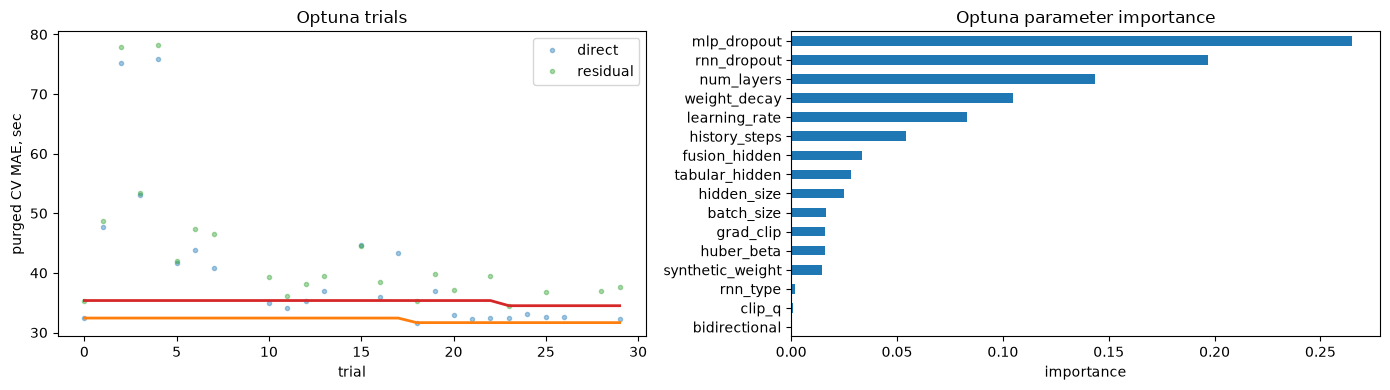

In [38]:
rnn_fig, rnn_axes = plt.subplots(1, 2, figsize=(14, 4))

for rnn_mode, rnn_study in rnn_studies.items():
    rnn_trials = rnn_study.trials_dataframe()
    rnn_complete = rnn_trials[
        rnn_trials.state == 'COMPLETE'
    ].copy()
    rnn_complete['best_so_far'] = rnn_complete.value.cummin()

    rnn_axes[0].plot(
        rnn_complete.number,
        rnn_complete.value,
        '.',
        alpha=.4,
        label=rnn_mode
    )
    rnn_axes[0].plot(
        rnn_complete.number,
        rnn_complete.best_so_far,
        linewidth=2
    )

rnn_axes[0].set_title('Optuna trials')
rnn_axes[0].set_xlabel('trial')
rnn_axes[0].set_ylabel('purged CV MAE, sec')
rnn_axes[0].legend()

rnn_best_mode_for_importance = rnn_study_table.iloc[0]['mode']
rnn_importance = optuna.importance.get_param_importances(
    rnn_studies[rnn_best_mode_for_importance]
)
pd.Series(rnn_importance).sort_values().plot.barh(ax=rnn_axes[1])
rnn_axes[1].set_title('Optuna parameter importance')
rnn_axes[1].set_xlabel('importance')

plt.tight_layout()

In [39]:
rnn_best_mode = rnn_study_table.iloc[0]['mode']
rnn_best_study = rnn_studies[rnn_best_mode]
rnn_best_params = rnn_complete_params(
    rnn_best_study.best_trial.params
)

pd.Series(rnn_best_params, name='value').to_frame()

,value
num_layers,3
rnn_type,LSTM
history_steps,20
hidden_size,96
bidirectional,True
rnn_dropout,0.143375
tabular_hidden,64
fusion_hidden,128
mlp_dropout,0.121808
learning_rate,0.001176


## 9. 5-fold OOF и test ensemble

После выбора гиперпараметров переобучаю лучшую конфигурацию на пяти purged folds.

Каждая fold-модель сразу предсказывает отдельный real `test`. Итоговый test prediction -- среднее пяти независимых fold-моделей. Test никак не участвует в early stopping.

In [40]:
def rnn_cv_ensemble(
    data,
    sequences,
    tabular,
    target,
    cur_dev,
    folds,
    mode,
    params,
    external_sequences=None,
    external_tabular=None,
    external_cur_dev=None,
    keep_models=False
):
    rnn_oof_parts = []
    rnn_histories = []
    rnn_external_predictions = []
    rnn_models = []
    rnn_bundles = []
    rnn_best_epochs = []

    for rnn_fold, (rnn_train_idx, rnn_valid_idx) in enumerate(folds):
        (
            rnn_model,
            rnn_bundle,
            rnn_valid_prediction,
            rnn_history,
            rnn_best_epoch
        ) = rnn_fit_fold(
            data,
            sequences,
            tabular,
            target,
            cur_dev,
            rnn_train_idx,
            rnn_valid_idx,
            mode,
            params,
            RNN_SEED + rnn_fold
        )

        rnn_part = data.iloc[rnn_valid_idx][
            ['sample_id', 'tr_id', 'T']
        ].copy()
        rnn_part['fold'] = rnn_fold
        rnn_part['target'] = target[rnn_valid_idx]
        rnn_part['prediction'] = rnn_valid_prediction
        rnn_part['error'] = rnn_part.target - rnn_part.prediction
        rnn_part['abs_error'] = rnn_part.error.abs()
        rnn_oof_parts.append(rnn_part)

        rnn_history = rnn_history.copy()
        rnn_history['fold'] = rnn_fold
        rnn_histories.append(rnn_history)
        rnn_best_epochs.append(rnn_best_epoch)

        if external_sequences is not None:
            rnn_external_predictions.append(
                rnn_predict_bundle(
                    rnn_model,
                    rnn_bundle,
                    external_sequences,
                    external_tabular,
                    external_cur_dev
                )
            )

        if keep_models:
            rnn_models.append(rnn_model.cpu())
            rnn_bundles.append(rnn_bundle)
        else:
            del rnn_model

        gc.collect()
        if RNN_DEVICE.type == 'mps':
            torch.mps.empty_cache()
        if RNN_DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    rnn_external_mean = None
    if len(rnn_external_predictions):
        rnn_external_mean = np.mean(
            np.vstack(rnn_external_predictions),
            axis=0
        )

    return (
        pd.concat(rnn_oof_parts, ignore_index=True),
        pd.concat(rnn_histories, ignore_index=True),
        np.array(rnn_best_epochs),
        rnn_external_mean,
        rnn_models,
        rnn_bundles
    )

In [41]:
(
    rnn_oof,
    rnn_oof_history,
    rnn_oof_best_epochs,
    rnn_test_prediction,
    _,
    _
) = rnn_cv_ensemble(
    rnn_train,
    rnn_train_sequences,
    rnn_train_tabular,
    rnn_y_train,
    rnn_cur_train,
    rnn_oof_folds,
    rnn_best_mode,
    rnn_best_params,
    external_sequences=rnn_test_sequences,
    external_tabular=rnn_test_tabular,
    external_cur_dev=rnn_test.cur_dev_s.to_numpy(float)
)

pd.Series({
    'purged_oof_mae': rnn_oof.abs_error.mean(),
    'median_best_epoch': np.median(rnn_oof_best_epochs),
    'min_best_epoch': rnn_oof_best_epochs.min(),
    'max_best_epoch': rnn_oof_best_epochs.max(),
})

purged_oof_mae       32.438299
median_best_epoch    56.000000
min_best_epoch       50.000000
max_best_epoch       69.000000
dtype: float64

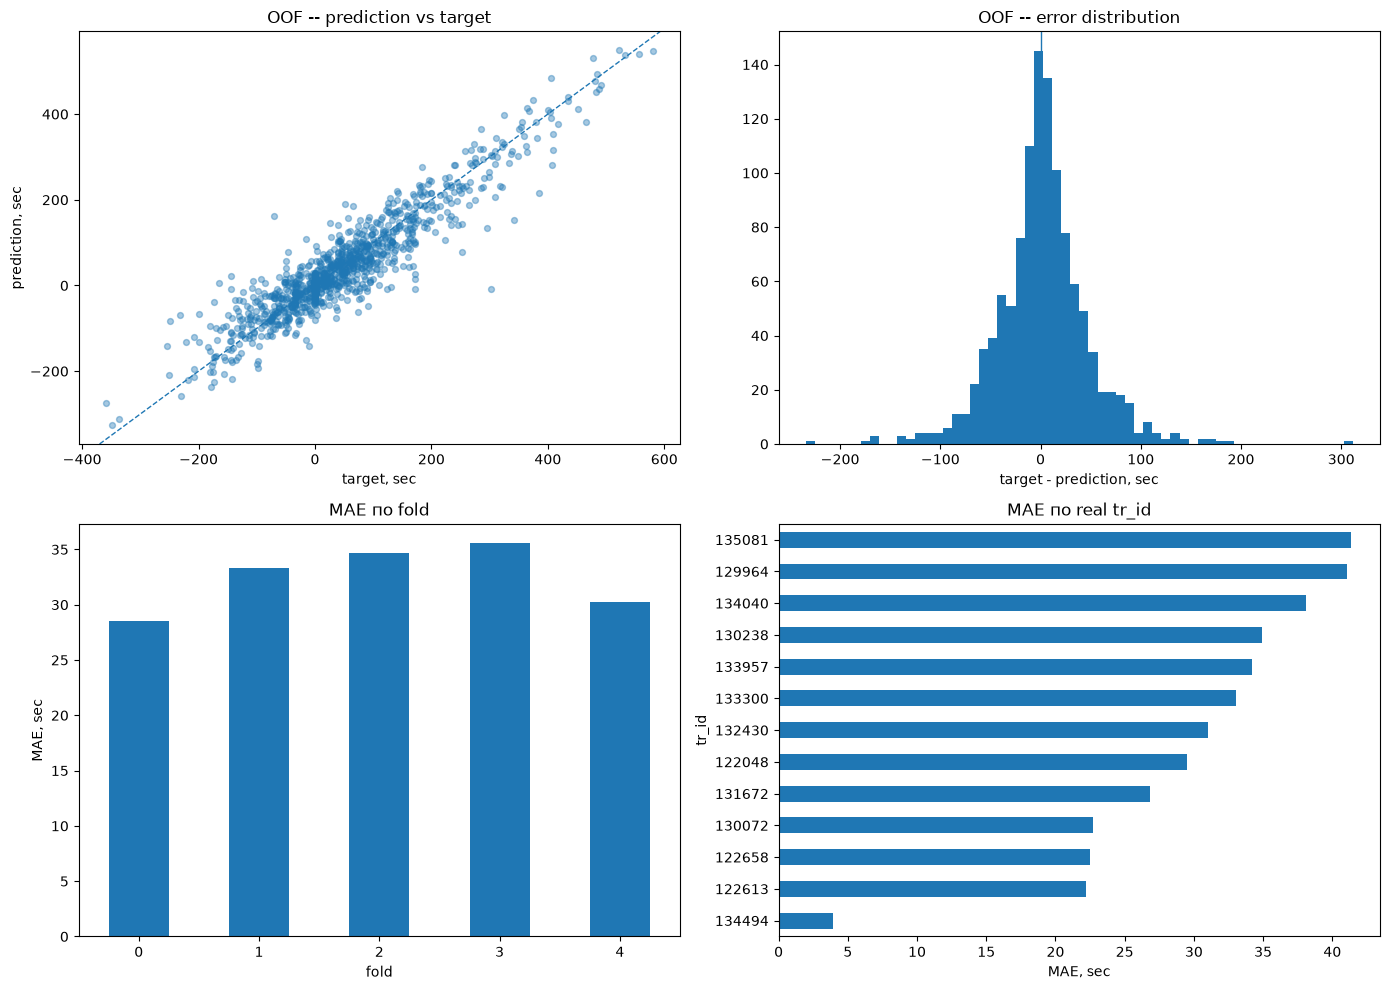

In [42]:
rnn_fig, rnn_axes = plt.subplots(2, 2, figsize=(14, 10))

rnn_axes[0, 0].scatter(
    rnn_oof.target,
    rnn_oof.prediction,
    s=18,
    alpha=.4
)
rnn_axes[0, 0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
rnn_axes[0, 0].set_title('OOF -- prediction vs target')
rnn_axes[0, 0].set_xlabel('target, sec')
rnn_axes[0, 0].set_ylabel('prediction, sec')

rnn_axes[0, 1].hist(rnn_oof.error, bins=60)
rnn_axes[0, 1].axvline(0, linewidth=1)
rnn_axes[0, 1].set_title('OOF -- error distribution')
rnn_axes[0, 1].set_xlabel('target - prediction, sec')

rnn_oof.groupby('fold').abs_error.mean().plot.bar(ax=rnn_axes[1, 0])
rnn_axes[1, 0].set_title('MAE по fold')
rnn_axes[1, 0].set_ylabel('MAE, sec')
rnn_axes[1, 0].tick_params(axis='x', rotation=0)

rnn_oof.groupby('tr_id').abs_error.mean().sort_values().plot.barh(
    ax=rnn_axes[1, 1]
)
rnn_axes[1, 1].set_title('MAE по real tr_id')
rnn_axes[1, 1].set_xlabel('MAE, sec')

plt.tight_layout()

### Learning curves по эпохам

Если validation MAE продолжает снижаться к последним эпохам, лимит обучения мал. Если train продолжает улучшаться, а validation разворачивается вверх -- сеть переобучается и regularization нужно усиливать.

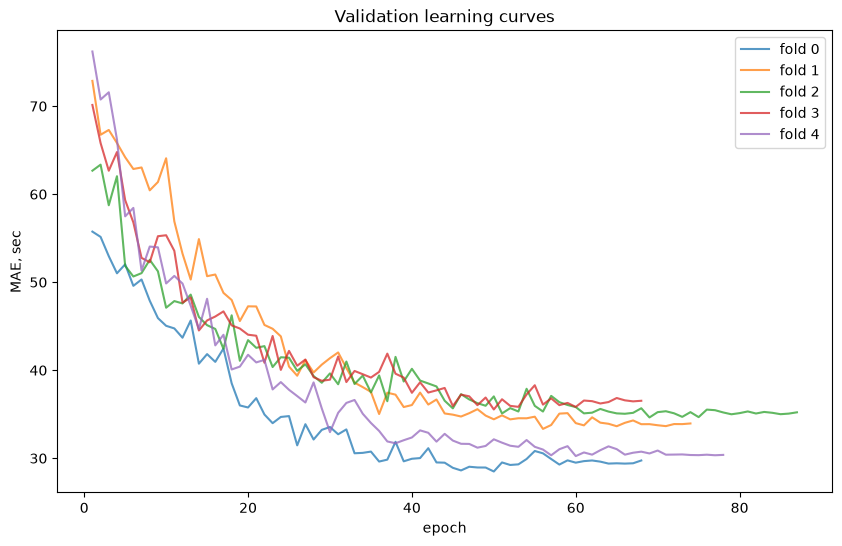

In [43]:
plt.figure(figsize=(10, 6))

for rnn_fold, rnn_history_part in rnn_oof_history.groupby('fold'):
    plt.plot(
        rnn_history_part.epoch,
        rnn_history_part.valid_mae,
        alpha=.75,
        label=f'fold {rnn_fold}'
    )

plt.title('Validation learning curves')
plt.xlabel('epoch')
plt.ylabel('MAE, sec')
plt.legend()
plt.show()

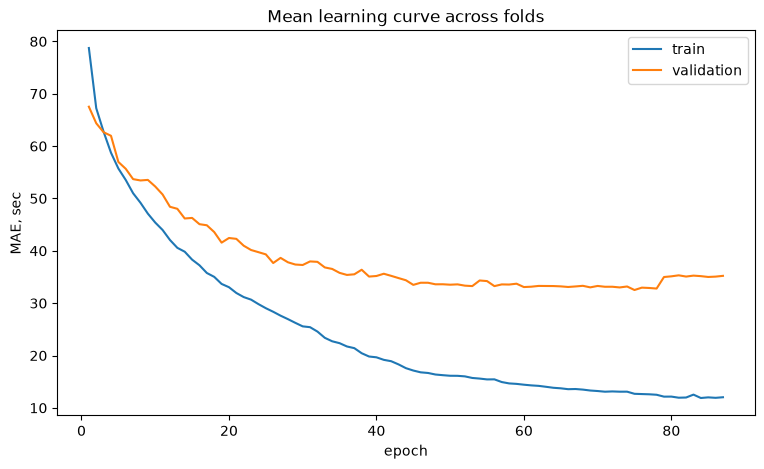

In [44]:
rnn_mean_history = (
    rnn_oof_history
    .groupby('epoch')[['train_mae', 'valid_mae']]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.plot(rnn_mean_history.index, rnn_mean_history.train_mae, label='train')
plt.plot(rnn_mean_history.index, rnn_mean_history.valid_mae, label='validation')
plt.title('Mean learning curve across folds')
plt.xlabel('epoch')
plt.ylabel('MAE, sec')
plt.legend()
plt.show()

### Test

До этой точки `test` использовался только как внешний набор для inference. Гиперпараметры и early stopping определены исключительно по train CV.

In [45]:
rnn_y_test = rnn_test.target_delay_s.to_numpy(float)
rnn_cur_test = rnn_test.cur_dev_s.to_numpy(float)

rnn_test_metrics = pd.Series({
    'sequence_rnn': mean_absolute_error(
        rnn_y_test,
        rnn_test_prediction
    ),
    'cur_dev_baseline': mean_absolute_error(
        rnn_y_test,
        rnn_cur_test
    ),
    'zero_baseline': mean_absolute_error(
        rnn_y_test,
        np.zeros(len(rnn_y_test))
    )
}).sort_values()

rnn_test_metrics

sequence_rnn         41.281711
cur_dev_baseline     93.359773
zero_baseline       103.337110
dtype: float64

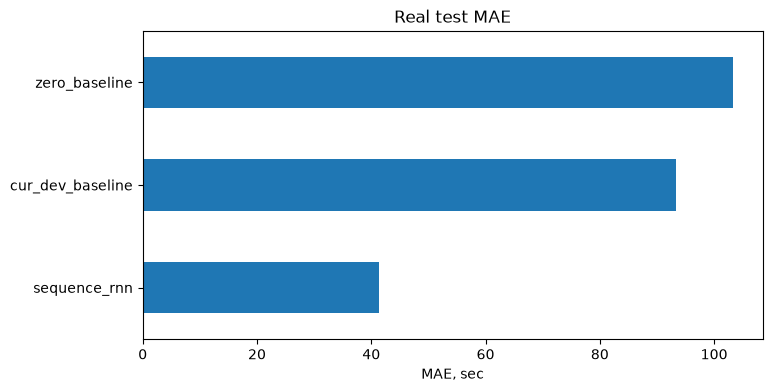

In [46]:
rnn_test_metrics.sort_values().plot.barh(figsize=(8, 4))
plt.title('Real test MAE')
plt.xlabel('MAE, sec')
plt.show()

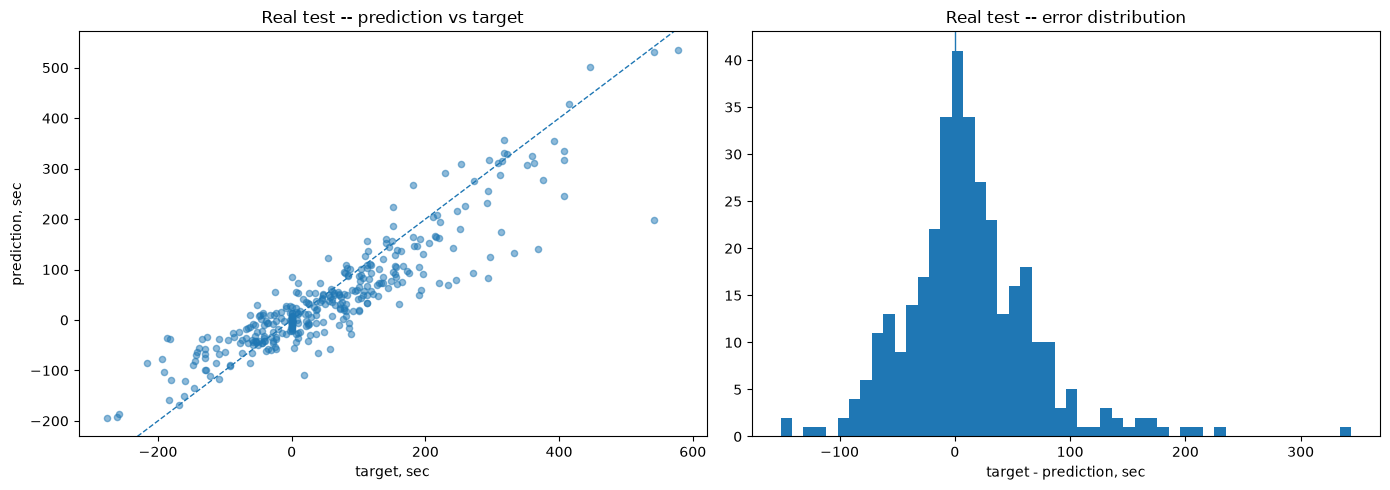

In [47]:
rnn_test_result = rnn_test[
    ['sample_id', 'tr_id', 'T']
].copy()
rnn_test_result['target'] = rnn_y_test
rnn_test_result['prediction'] = rnn_test_prediction
rnn_test_result['error'] = rnn_test_result.target - rnn_test_result.prediction
rnn_test_result['abs_error'] = rnn_test_result.error.abs()

rnn_fig, rnn_axes = plt.subplots(1, 2, figsize=(14, 5))
rnn_axes[0].scatter(
    rnn_test_result.target,
    rnn_test_result.prediction,
    s=20,
    alpha=.5
)
rnn_axes[0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
rnn_axes[0].set_title('Real test -- prediction vs target')
rnn_axes[0].set_xlabel('target, sec')
rnn_axes[0].set_ylabel('prediction, sec')

rnn_axes[1].hist(rnn_test_result.error, bins=50)
rnn_axes[1].axvline(0, linewidth=1)
rnn_axes[1].set_title('Real test -- error distribution')
rnn_axes[1].set_xlabel('target - prediction, sec')

plt.tight_layout()

## 10. Stress-test на невиданных ТС

Hidden validate использует знакомые реальные `tr_id`, поэтому этот split жестче основной задачи. Он нужен как диагностика того, насколько сеть выучила общую физику движения, а не только особенности конкретных ТС.

In [48]:
(
    rnn_stress_oof,
    _,
    _,
    _,
    _,
    _
) = rnn_cv_ensemble(
    rnn_train,
    rnn_train_sequences,
    rnn_train_tabular,
    rnn_y_train,
    rnn_cur_train,
    rnn_stress_folds,
    rnn_best_mode,
    rnn_best_params
)

pd.Series({
    'purged_oof_mae': rnn_oof.abs_error.mean(),
    'unseen_tr_id_mae': rnn_stress_oof.abs_error.mean()
})

purged_oof_mae      32.438299
unseen_tr_id_mae    30.843197
dtype: float64

## 11. Learning curve по объему train

Дополнительно уменьшаю train первого purged fold. Validation остается фиксированным. Это показывает, уперлась ли модель в объем размеченных данных.

In [49]:
def rnn_fraction_train_idx(data, train_idx, fraction, seed):
    if fraction >= 1:
        return train_idx

    rnn_rng = np.random.default_rng(seed)
    rnn_train_data = data.iloc[train_idx]
    rnn_real = train_idx[
        rnn_train_data.tr_id.to_numpy() < 9_000_000
    ]
    rnn_synthetic = train_idx[
        rnn_train_data.tr_id.to_numpy() >= 9_000_000
    ]

    rnn_real_n = max(1, int(np.ceil(len(rnn_real) * fraction)))
    rnn_synthetic_n = int(np.ceil(len(rnn_synthetic) * fraction))

    rnn_selected_real = rnn_rng.choice(
        rnn_real,
        size=rnn_real_n,
        replace=False
    )
    rnn_selected_synthetic = rnn_rng.choice(
        rnn_synthetic,
        size=rnn_synthetic_n,
        replace=False
    ) if rnn_synthetic_n else np.array([], dtype=int)

    return np.sort(np.concatenate([
        rnn_selected_real,
        rnn_selected_synthetic
    ]))

In [50]:
def rnn_data_learning_curve(
    data,
    sequences,
    tabular,
    target,
    cur_dev,
    fold,
    mode,
    params,
    fractions
):
    rnn_train_idx, rnn_valid_idx = fold
    rnn_rows = []

    for rnn_fraction in fractions:
        rnn_fraction_idx = rnn_fraction_train_idx(
            data,
            rnn_train_idx,
            rnn_fraction,
            RNN_SEED
        )
        (
            rnn_model,
            _,
            rnn_prediction,
            _,
            rnn_best_epoch
        ) = rnn_fit_fold(
            data,
            sequences,
            tabular,
            target,
            cur_dev,
            rnn_fraction_idx,
            rnn_valid_idx,
            mode,
            params,
            RNN_SEED
        )

        rnn_rows.append({
            'train_fraction': rnn_fraction,
            'train_rows': len(rnn_fraction_idx),
            'valid_mae': mean_absolute_error(
                target[rnn_valid_idx],
                rnn_prediction
            ),
            'best_epoch': rnn_best_epoch
        })
        del rnn_model
        gc.collect()

    return pd.DataFrame(rnn_rows)

In [51]:
rnn_data_curve = rnn_data_learning_curve(
    rnn_train,
    rnn_train_sequences,
    rnn_train_tabular,
    rnn_y_train,
    rnn_cur_train,
    rnn_oof_folds[0],
    rnn_best_mode,
    rnn_best_params,
    RNN_LEARNING_FRACTIONS
)

rnn_data_curve

,train_fraction,train_rows,valid_mae,best_epoch
0,0.25,1034,53.906734,3
1,0.50,2066,39.848570,59
2,0.75,3098,33.084199,38
3,1.00,4130,28.494100,50


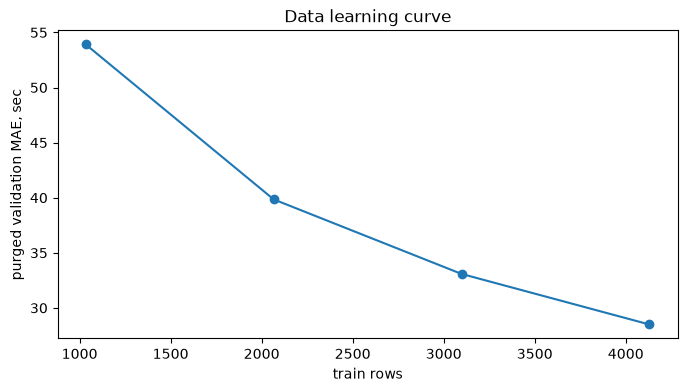

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(
    rnn_data_curve.train_rows,
    rnn_data_curve.valid_mae,
    marker='o'
)
plt.title('Data learning curve')
plt.xlabel('train rows')
plt.ylabel('purged validation MAE, sec')
plt.show()

## 12. Final retune на train + test

Только после фиксации unbiased test MAE добавляю test labels к обучению.

На объединенных данных делаю короткий final Optuna refinement и затем обучаю 5 purged fold-моделей. Их средний прогноз идет в hidden validate.

In [53]:
rnn_all = pd.concat(
    [rnn_train, rnn_test],
    ignore_index=True
)
rnn_all_sequences = np.concatenate([
    rnn_train_sequences,
    rnn_test_sequences
])
rnn_all_tabular = np.concatenate([
    rnn_train_tabular,
    rnn_test_tabular
])
rnn_y_all = rnn_all.target_delay_s.to_numpy(float)
rnn_cur_all = rnn_all.cur_dev_s.to_numpy(float)

rnn_final_folds = rnn_build_purged_folds(
    rnn_all,
    RNN_OOF_FOLDS
)
rnn_check_folds(rnn_all, rnn_final_folds)

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min,synthetic_valid_rows
0,0,4395,304,13,50.0,0
1,1,4319,301,13,50.0,0
2,2,4296,301,13,50.0,0
3,3,4300,297,13,50.0,0
4,4,4414,291,13,50.0,0


In [54]:
rnn_final_study = optuna.create_study(
    study_name=f'sequence_rnn_{rnn_best_mode}_final',
    storage=rnn_storage,
    load_if_exists=True,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RNN_SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )
)

if len(rnn_final_study.trials) == 0:
    rnn_final_study.enqueue_trial(rnn_best_study.best_trial.params)

rnn_final_finished = sum(
    rnn_trial.state in {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED
    }
    for rnn_trial in rnn_final_study.trials
)
rnn_final_remaining = max(
    0,
    RNN_FINAL_TRIALS - rnn_final_finished
)

if rnn_final_remaining:
    rnn_final_study.optimize(
        lambda rnn_trial: rnn_objective(
            rnn_trial,
            rnn_best_mode,
            rnn_all,
            rnn_all_sequences,
            rnn_all_tabular,
            rnn_y_all,
            rnn_cur_all,
            rnn_final_folds
        ),
        n_trials=rnn_final_remaining,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=False
    )

rnn_final_params = rnn_complete_params(
    rnn_final_study.best_trial.params
)
pd.Series(rnn_final_params, name='value').to_frame()

[I 2026-09-27 07:17:10,386] A new study created in RDB with name: sequence_rnn_direct_final
[I 2026-09-27 07:25:16,240] Trial 0 finished with value: 33.63900709939084 and parameters: {'num_layers': 3, 'rnn_type': 'LSTM', 'history_steps': 20, 'hidden_size': 96, 'bidirectional': True, 'rnn_dropout': 0.14337466550235295, 'tabular_hidden': 64, 'fusion_hidden': 128, 'mlp_dropout': 0.12180844304622718, 'learning_rate': 0.0011759850889109282, 'weight_decay': 0.00014021027621985056, 'batch_size': 64, 'huber_beta': 0.5, 'grad_clip': 1.0, 'synthetic_weight': 0.75, 'clip_q': 'q999'}. Best is trial 0 with value: 33.63900709939084.
[I 2026-09-27 07:37:31,745] Trial 1 finished with value: 32.658697375508126 and parameters: {'num_layers': 3, 'rnn_type': 'LSTM', 'history_steps': 20, 'hidden_size': 96, 'bidirectional': True, 'rnn_dropout': 0.24371820172525102, 'tabular_hidden': 96, 'fusion_hidden': 64, 'mlp_dropout': 0.12630777354553704, 'learning_rate': 0.0008229421352700022, 'weight_decay': 6.0523233

,value
num_layers,3
rnn_type,LSTM
history_steps,20
hidden_size,96
bidirectional,True
rnn_dropout,0.243718
tabular_hidden,96
fusion_hidden,64
mlp_dropout,0.126308
learning_rate,0.000823


In [55]:
(
    rnn_final_oof,
    rnn_final_history,
    rnn_final_best_epochs,
    rnn_validate_prediction,
    rnn_final_models,
    rnn_final_bundles
) = rnn_cv_ensemble(
    rnn_all,
    rnn_all_sequences,
    rnn_all_tabular,
    rnn_y_all,
    rnn_cur_all,
    rnn_final_folds,
    rnn_best_mode,
    rnn_final_params,
    external_sequences=rnn_validate_sequences,
    external_tabular=rnn_validate_tabular,
    external_cur_dev=rnn_validate.cur_dev_s.to_numpy(float),
    keep_models=True
)

pd.Series({
    'final_internal_cv_mae': rnn_final_oof.abs_error.mean(),
    'ensemble_models': len(rnn_final_models),
    'median_best_epoch': np.median(rnn_final_best_epochs),
})

final_internal_cv_mae    32.653953
ensemble_models           5.000000
median_best_epoch        69.000000
dtype: float64

## 13. Submission

In [56]:
rnn_submission_template = pd.read_csv(
    '../dataset/sample_submission.csv',
    sep=';'
)
rnn_prediction_map = pd.Series(
    rnn_validate_prediction,
    index=rnn_validate.sample_id
)
rnn_submission = rnn_submission_template.copy()
rnn_submission['prediction'] = rnn_submission.sample_id.map(
    rnn_prediction_map
)

assert rnn_submission.prediction.notna().all()
assert rnn_submission.sample_id.is_unique

rnn_submission_path = (
    RNN_SUBMISSION_DIR
    / f'sequence_rnn_{rnn_best_mode}_ensemble.csv'
)
rnn_submission.to_csv(
    rnn_submission_path,
    sep=';',
    index=False
)

rnn_submission_path

PosixPath('../submissions/sequence_rnn/sequence_rnn_direct_ensemble.csv')

## 14. Сохранение весов и артефактов

Сохраняю не только `state_dict`, но и preprocessing каждого fold. Это обязательно: sequence scaler, tabular imputer/scaler, target scaling и clipping являются частью модели.

Итоговый inference -- среднее пяти final fold-моделей.

In [57]:
for rnn_fold, (rnn_model, rnn_bundle) in enumerate(
    zip(rnn_final_models, rnn_final_bundles)
):
    rnn_model_config = {
        'sequence_dim': len(RNN_SEQUENCE_FEATURES),
        'tabular_dim': len(rnn_tabular_features),
        **{
            rnn_key: rnn_final_params[rnn_key]
            for rnn_key in [
                'rnn_type',
                'hidden_size',
                'num_layers',
                'bidirectional',
                'rnn_dropout',
                'tabular_hidden',
                'fusion_hidden',
                'mlp_dropout'
            ]
        }
    }

    torch.save(
        {
            'state_dict': rnn_model.state_dict(),
            'model_config': rnn_model_config,
        },
        RNN_CHECKPOINT_DIR / f'fold_{rnn_fold}.pt'
    )

    with open(
        RNN_CHECKPOINT_DIR / f'fold_{rnn_fold}_preprocessing.pkl',
        'wb'
    ) as rnn_file:
        pickle.dump(rnn_bundle, rnn_file)

In [58]:
rnn_oof.to_csv(
    RNN_ARTIFACT_DIR / 'train_oof_predictions.csv',
    index=False
)
rnn_test_result.to_csv(
    RNN_ARTIFACT_DIR / 'test_predictions.csv',
    index=False
)
rnn_final_oof.to_csv(
    RNN_ARTIFACT_DIR / 'final_train_test_oof_predictions.csv',
    index=False
)
rnn_oof_history.to_csv(
    RNN_ARTIFACT_DIR / 'train_oof_history.csv',
    index=False
)
rnn_final_history.to_csv(
    RNN_ARTIFACT_DIR / 'final_history.csv',
    index=False
)
rnn_studies['direct'].trials_dataframe().to_csv(
    RNN_ARTIFACT_DIR / 'optuna_direct_trials.csv',
    index=False
)
rnn_studies['residual'].trials_dataframe().to_csv(
    RNN_ARTIFACT_DIR / 'optuna_residual_trials.csv',
    index=False
)
rnn_final_study.trials_dataframe().to_csv(
    RNN_ARTIFACT_DIR / 'optuna_final_trials.csv',
    index=False
)

In [59]:
rnn_metadata = {
    'seed': RNN_SEED,
    'device_used_for_training': str(RNN_DEVICE),
    'mode': rnn_best_mode,
    'sequence_steps': RNN_SEQUENCE_STEPS,
    'sequence_step_seconds': RNN_STEP_SECONDS,
    'sequence_features': RNN_SEQUENCE_FEATURES,
    'tabular_features': rnn_tabular_features,
    'best_train_params': rnn_best_params,
    'final_params': rnn_final_params,
    'train_purged_oof_mae': float(rnn_oof.abs_error.mean()),
    'unseen_tr_id_mae': float(rnn_stress_oof.abs_error.mean()),
    'real_test_mae': float(mean_absolute_error(
        rnn_y_test,
        rnn_test_prediction
    )),
    'final_internal_cv_mae': float(rnn_final_oof.abs_error.mean()),
    'final_best_epochs': rnn_final_best_epochs.tolist(),
    'submission': str(rnn_submission_path),
}

with open(
    RNN_ARTIFACT_DIR / 'metadata.json',
    'w',
    encoding='utf-8'
) as rnn_file:
    json.dump(
        rnn_metadata,
        rnn_file,
        ensure_ascii=False,
        indent=2
    )

RNN_ARTIFACT_DIR

PosixPath('../artifacts/models/sequence_rnn')

In [60]:
pd.DataFrame({
    'artifact': [
        'weights',
        'preprocessing',
        'metadata',
        'OOF predictions',
        'test predictions',
        'training history',
        'Optuna studies',
        'submission'
    ],
    'location': [
        str(RNN_CHECKPOINT_DIR / 'fold_*.pt'),
        str(RNN_CHECKPOINT_DIR / 'fold_*_preprocessing.pkl'),
        str(RNN_ARTIFACT_DIR / 'metadata.json'),
        str(RNN_ARTIFACT_DIR / 'train_oof_predictions.csv'),
        str(RNN_ARTIFACT_DIR / 'test_predictions.csv'),
        str(RNN_ARTIFACT_DIR / 'final_history.csv'),
        str(RNN_ARTIFACT_DIR / 'optuna.db'),
        str(rnn_submission_path)
    ]
})

,artifact,location
0,weights,../artifacts/models/sequence_rnn/checkpoints/f...
1,preprocessing,../artifacts/models/sequence_rnn/checkpoints/f...
2,metadata,../artifacts/models/sequence_rnn/metadata.json
3,OOF predictions,../artifacts/models/sequence_rnn/train_oof_pre...
4,test predictions,../artifacts/models/sequence_rnn/test_predicti...
5,training history,../artifacts/models/sequence_rnn/final_history...
6,Optuna studies,../artifacts/models/sequence_rnn/optuna.db
7,submission,../submissions/sequence_rnn/sequence_rnn_direc...


## Что смотреть после обучения

Если GRU выигрывает LSTM и `history_steps` стабильно короткий -- данные в основном локальные, усложнять sequence encoder пока не нужно.

Если LSTM / bidirectional / длинные 30 минут стабильно выигрывают -- есть смысл следующим шагом проверить TCN и attention поверх recurrent states.

Если neural model проигрывает CatBoost при хорошем train convergence -- это тоже полезный результат: размеченных точек мало, и основной сигнал лучше извлекается из агрегированных физических признаков. Тогда разумнее ансамблировать CatBoost с sequence-моделью, а не увеличивать сеть.